[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


STEP 1: LOADING DATA
Dataset Shape: (10000, 8)
Columns: ['index', 'text', 'label', 'source', 'text_word_count', 'label_cat', 'source_int', 'processed_text']

First rows
   index                                               text  label  source  \
0     47  All the Love you do not see\n\nOn writing with...      0  medium   
1     85  Reading, writing and displaying images\n\nBefo...      0  medium   
2    255  Why I Think “Target Audience” Doesn’t Always M...      0  medium   
3    268  All sorts of books are published every year, a...      0  medium   
4    315  Finding The Right Question Not Answer\n\nWhen ...      0  medium   

   text_word_count label_cat  source_int  \
0              236     human           0   
1              386     human           0   
2              323     human           0   
3              176     human           0   
4              264     human           0   

                                      processed_text  
0  love see write heart hope photo joshua 

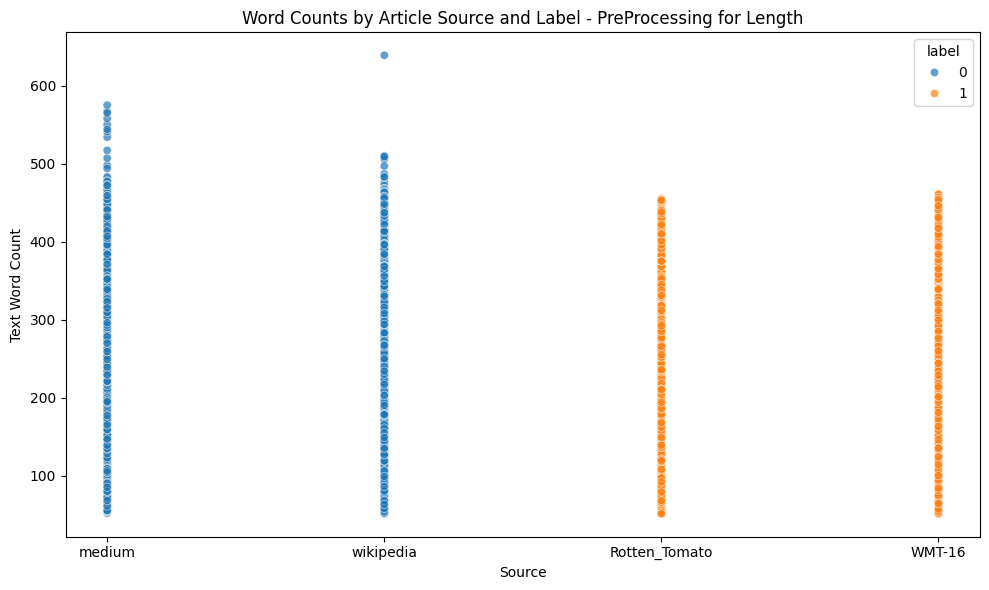


STEP 2: CLEANING DATA
Dropped rows: 222
Final shape: (9640, 11)


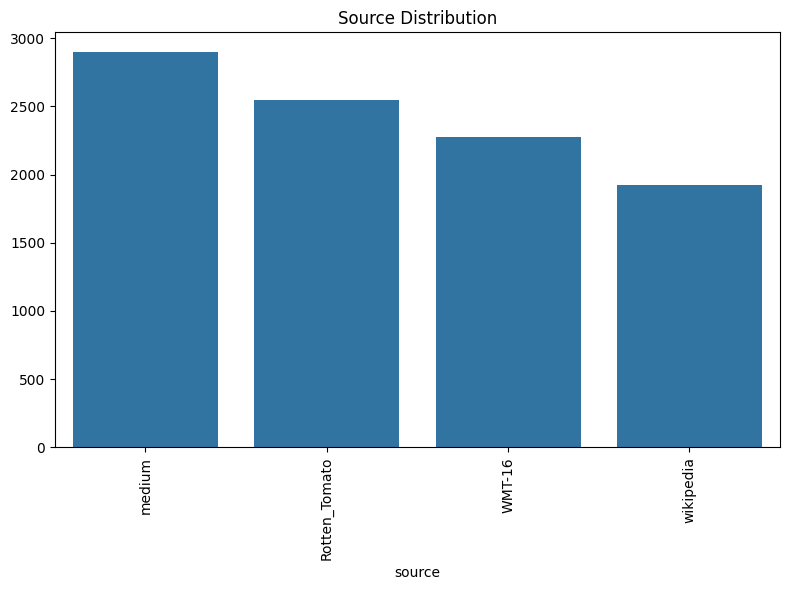

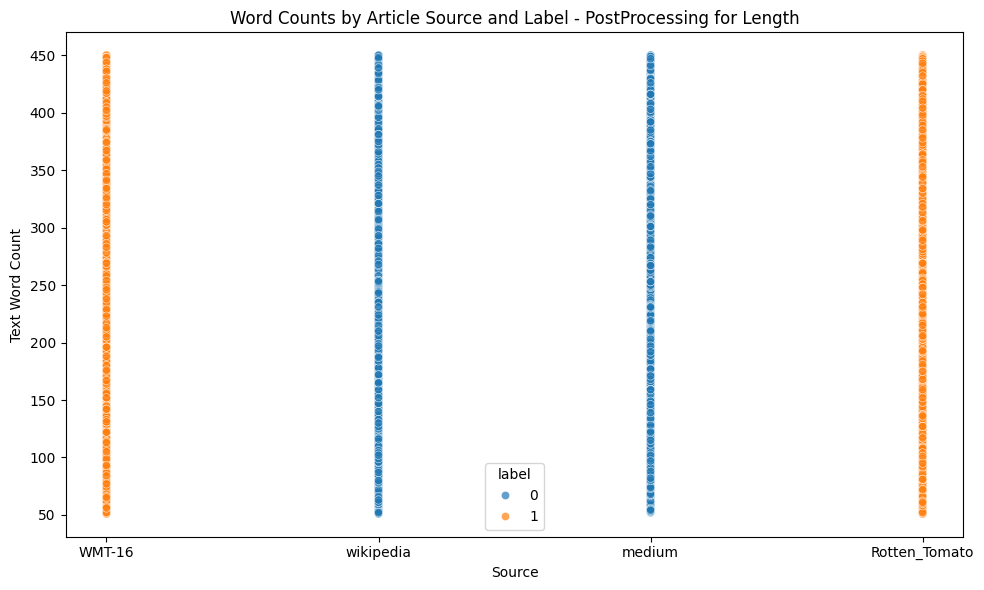


STEP 3: TRAIN TEST SPLIT
Train size: 7712
Test size: 1928
BoW shape: (7712, 10000)
TFIDF shape: (7712, 12643)
Loading BERT model


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: sentence-transformers/all-distilroberta-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/241 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]


Training: Logistic Regression with BoW
CV F1: 0.8937684153260226
Accuracy: 0.9056016597510373
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       964
           1       0.91      0.91      0.91       964

    accuracy                           0.91      1928
   macro avg       0.91      0.91      0.91      1928
weighted avg       0.91      0.91      0.91      1928


Training: Random Forest with BoW
CV F1: 0.8928644232852821
Accuracy: 0.9004149377593361
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       964
           1       0.86      0.95      0.91       964

    accuracy                           0.90      1928
   macro avg       0.90      0.90      0.90      1928
weighted avg       0.90      0.90      0.90      1928


Training: XGBoost with BoW
CV F1: 0.8998501851593068
Accuracy: 0.9056016597510373
              precision    recall  f1-score   support

           0       0.96 

In [7]:
import re
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import nltk
nltk.download('stopwords')
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from scipy.sparse import hstack
from xgboost import XGBClassifier

import nltk
from nltk.corpus import stopwords
from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt


# -------------------------------------------------------------
# Helper Functions
# -------------------------------------------------------------
def _show_plt(fig=None):
    """Display matplotlib figure"""
    target = fig if fig is not None else plt.gcf()

    try:
        from IPython.display import display
        display(target)
    except Exception:
        pass

    plt.show()
    plt.close("all")


# -------------------------------------------------------------
# Main Class
# -------------------------------------------------------------
class AITextDetector:

    def __init__(self, data_path: str):

        self.data_path = data_path
        self.df = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.results = {}

        self._tfidf_vectorizer = None
        self._bow_vectorizer = None
        self._bert_model = None

        self._X_train_tfidf = None
        self._X_test_tfidf = None

        self._X_train_bow = None
        self._X_test_bow = None

        self._X_train_bert = None
        self._X_test_bert = None

    # ---------------------------------------------------------
    # STEP 1: LOAD DATA
    # ---------------------------------------------------------
    def load_and_explore_data(self):

        print("=" * 80)
        print("STEP 1: LOADING DATA")
        print("=" * 80)

        self.df = pd.read_csv(self.data_path)

        print("Dataset Shape:", self.df.shape)
        print("Columns:", self.df.columns.tolist())

        print("\nFirst rows")
        print(self.df.head())

        print("\nLabel distribution")
        print(self.df['label'].value_counts())

        return self.df
    def precharts(self):
        df = self.df
        plt.figure(figsize=(10,6))
        if 'text_word_count_pre' not in df.columns:
          df['text_word_count_pre'] = df['text'].astype(str).apply(
            lambda x: len(x.split())
        )
        sns.scatterplot(
            data=df,
            x='source',
            y='text_word_count_pre',
            hue='label',
            alpha=0.7
        )

        plt.title(
            "Word Counts by Article Source and Label - PreProcessing for Length"
        )

        plt.xlabel("Source")
        plt.ylabel("Text Word Count")

        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # TEXT PREPROCESSING
    # ---------------------------------------------------------
    @staticmethod
    def _preprocess(text: str):

        text = str(text).lower()
        text = re.sub(r"\s+", " ", text)

        return text.strip()

    # ---------------------------------------------------------
    # STEP 2: CLEAN DATA
    # ---------------------------------------------------------
    def clean_data(self):

        print("\n" + "=" * 80)
        print("STEP 2: CLEANING DATA")
        print("=" * 80)

        text_col = "text"
        label_col = "label"

        self.df["cleaned_text"] = self.df[text_col].apply(self._preprocess)

        self.df["word_count"] = self.df["cleaned_text"].apply(
            lambda x: len(x.split())
        )

        self.df = self.df[self.df["cleaned_text"].str.strip() != ""]

        before = len(self.df)

        self.df = self.df[
            (self.df["word_count"] >= 50) &
            (self.df["word_count"] <= 450)
        ]

        print("Dropped rows:", before - len(self.df))

        human_df = self.df[self.df[label_col] == 0]
        machine_df = self.df[self.df[label_col] == 1]

        n = min(len(human_df), len(machine_df))

        self.df = pd.concat([
            human_df.sample(n, random_state=42),
            machine_df.sample(n, random_state=42)
        ]).sample(frac=1, random_state=42).reset_index(drop=True)

        print("Final shape:", self.df.shape)

        return self.df
    def charts(self):

        df = self.df

        if 'source' not in df.columns:
            print("Source column not available, skipping chart.")
            return

        # ---------------------------------------------------
        # Source Distribution
        # ---------------------------------------------------

        plt.figure(figsize=(8,6))

        source_counts = df['source'].value_counts()

        sns.barplot(
            x=source_counts.index,
            y=source_counts.values
        )

        plt.title("Source Distribution")
        plt.xticks(rotation=90)

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------
        # Word Count vs Source (Post Processing)
        # ---------------------------------------------------

        plt.figure(figsize=(10,6))
        if 'text_word_count_post' not in df.columns:
          df['text_word_count_post'] = df['cleaned_text'].astype(str).apply(
            lambda x: len(x.split())
        )
        sns.scatterplot(
            data=df,
            x='source',
            y='text_word_count_post',
            hue='label',
            alpha=0.7
        )

        plt.title(
            "Word Counts by Article Source and Label - PostProcessing for Length"
        )

        plt.xlabel("Source")
        plt.ylabel("Text Word Count")

        plt.tight_layout()
        plt.show()
    # ---------------------------------------------------------
    # STEP 3: SPLIT DATA
    # ---------------------------------------------------------
    def split_data(self):

        print("\n" + "=" * 80)
        print("STEP 3: TRAIN TEST SPLIT")
        print("=" * 80)

        X = self.df["cleaned_text"]
        y = self.df["label"]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            stratify=y,
            random_state=42
        )

        print("Train size:", len(self.X_train))
        print("Test size:", len(self.X_test))

    # ---------------------------------------------------------
    # BAG OF WORDS
    # ---------------------------------------------------------
    def create_bow_vectors(self):

        if self._X_train_bow is not None:
            return self._X_train_bow, self._X_test_bow

        vectorizer = CountVectorizer(
            ngram_range=(1, 2),
            stop_words=stopwords.words("english"),
            max_features=10000
        )

        X_train = vectorizer.fit_transform(self.X_train)
        X_test = vectorizer.transform(self.X_test)

        self._bow_vectorizer = vectorizer
        self._X_train_bow = X_train
        self._X_test_bow = X_test

        print("BoW shape:", X_train.shape)

        return X_train, X_test

    # ---------------------------------------------------------
    # TFIDF
    # ---------------------------------------------------------
    def create_tfidf_vectors(self):

        if self._X_train_tfidf is not None:
            return self._X_train_tfidf, self._X_test_tfidf

        vectorizer = TfidfVectorizer(
            ngram_range=(1, 2),
            stop_words=stopwords.words("english"),
            min_df=10
        )

        X_train = vectorizer.fit_transform(self.X_train)
        X_test = vectorizer.transform(self.X_test)

        self._tfidf_vectorizer = vectorizer
        self._X_train_tfidf = X_train
        self._X_test_tfidf = X_test

        print("TFIDF shape:", X_train.shape)

        return X_train, X_test

    # ---------------------------------------------------------
    # BERT EMBEDDINGS
    # ---------------------------------------------------------
    def create_bert_embeddings(self):

        if self._X_train_bert is not None:
            return self._X_train_bert, self._X_test_bert

        print("Loading BERT model")

        model = SentenceTransformer("all-distilroberta-v1")

        X_train = model.encode(self.X_train.tolist(), show_progress_bar=True)
        X_test = model.encode(self.X_test.tolist(), show_progress_bar=True)

        self._bert_model = model
        self._X_train_bert = X_train
        self._X_test_bert = X_test

        return X_train, X_test

    # ---------------------------------------------------------
    # TRAIN MODEL
    # ---------------------------------------------------------
    def train_model(self, X_train, X_test, model_name, vec_name):

        print("\nTraining:", model_name, "with", vec_name)

        if model_name == "Logistic Regression":
            model = LogisticRegression(max_iter=1000)

        elif model_name == "Random Forest":
            model = RandomForestClassifier(n_estimators=200)

        else:
            model = XGBClassifier(eval_metric="logloss")

        cv = cross_val_score(model, X_train, self.y_train, cv=3, scoring="f1")
        print("CV F1:", cv.mean())

        start = time.time()

        model.fit(X_train, self.y_train)

        elapsed = time.time() - start

        preds = model.predict(X_test)

        acc = accuracy_score(self.y_test, preds)
        prec = precision_score(self.y_test, preds, average="weighted")
        rec = recall_score(self.y_test, preds, average="weighted")
        f1 = f1_score(self.y_test, preds, average="weighted")

        key = model_name + "_" + vec_name

        self.results[key] = {
            "accuracy": acc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "training_time": elapsed
        }

        print("Accuracy:", acc)
        print(classification_report(self.y_test, preds))

    # ---------------------------------------------------------
    # RUN EXPERIMENTS
    # ---------------------------------------------------------
    def run_traditional_ml_experiments(self):

        X_train_bow, X_test_bow = self.create_bow_vectors()
        X_train_tfidf, X_test_tfidf = self.create_tfidf_vectors()
        X_train_bert, X_test_bert = self.create_bert_embeddings()

        models = [
            "Logistic Regression",
            "Random Forest",
            "XGBoost"
        ]

        for vec_name, Xtr, Xte in [
            ("BoW", X_train_bow, X_test_bow),
            ("TFIDF", X_train_tfidf, X_test_tfidf),
            ("BERT", X_train_bert, X_test_bert)
        ]:

            for model in models:
                self.train_model(Xtr, Xte, model, vec_name)

    # ---------------------------------------------------------
    # FINAL REPORT
    # ---------------------------------------------------------
    def generate_final_report(self):

        print("\nFINAL RESULTS")

        rows = []

        for k, v in self.results.items():

            rows.append({
                "Model": k,
                "Accuracy": v["accuracy"],
                "F1": v["f1"],
                "Time": v["training_time"]
            })

        df = pd.DataFrame(rows)

        print(df)

        best = df.sort_values("F1", ascending=False).iloc[0]

        print("\nBest Model:", best["Model"])


# -------------------------------------------------------------
# MAIN FUNCTION
# -------------------------------------------------------------
def main():

    DATA_PATH = "/content/5000human_5000machine.csv"

    detector = AITextDetector(DATA_PATH)

    detector.load_and_explore_data()
    detector.precharts()
    detector.clean_data()
    detector.charts()
    detector.split_data()

    detector.run_traditional_ml_experiments()

    detector.generate_final_report()


if __name__ == "__main__":
    main()

Dataset shape: (10000, 8)
   index                                               text  label  source  \
0     47  All the Love you do not see\n\nOn writing with...      0  medium   
1     85  Reading, writing and displaying images\n\nBefo...      0  medium   
2    255  Why I Think “Target Audience” Doesn’t Always M...      0  medium   
3    268  All sorts of books are published every year, a...      0  medium   
4    315  Finding The Right Question Not Answer\n\nWhen ...      0  medium   

   text_word_count label_cat  source_int  \
0              236     human           0   
1              386     human           0   
2              323     human           0   
3              176     human           0   
4              264     human           0   

                                      processed_text  
0  love see write heart hope photo joshua coleman...  
1  read write display image anything computer vis...  
2  think target audience always matter much first...  
3  sort book publish

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generating BERT embeddings...


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Computing UMAP...


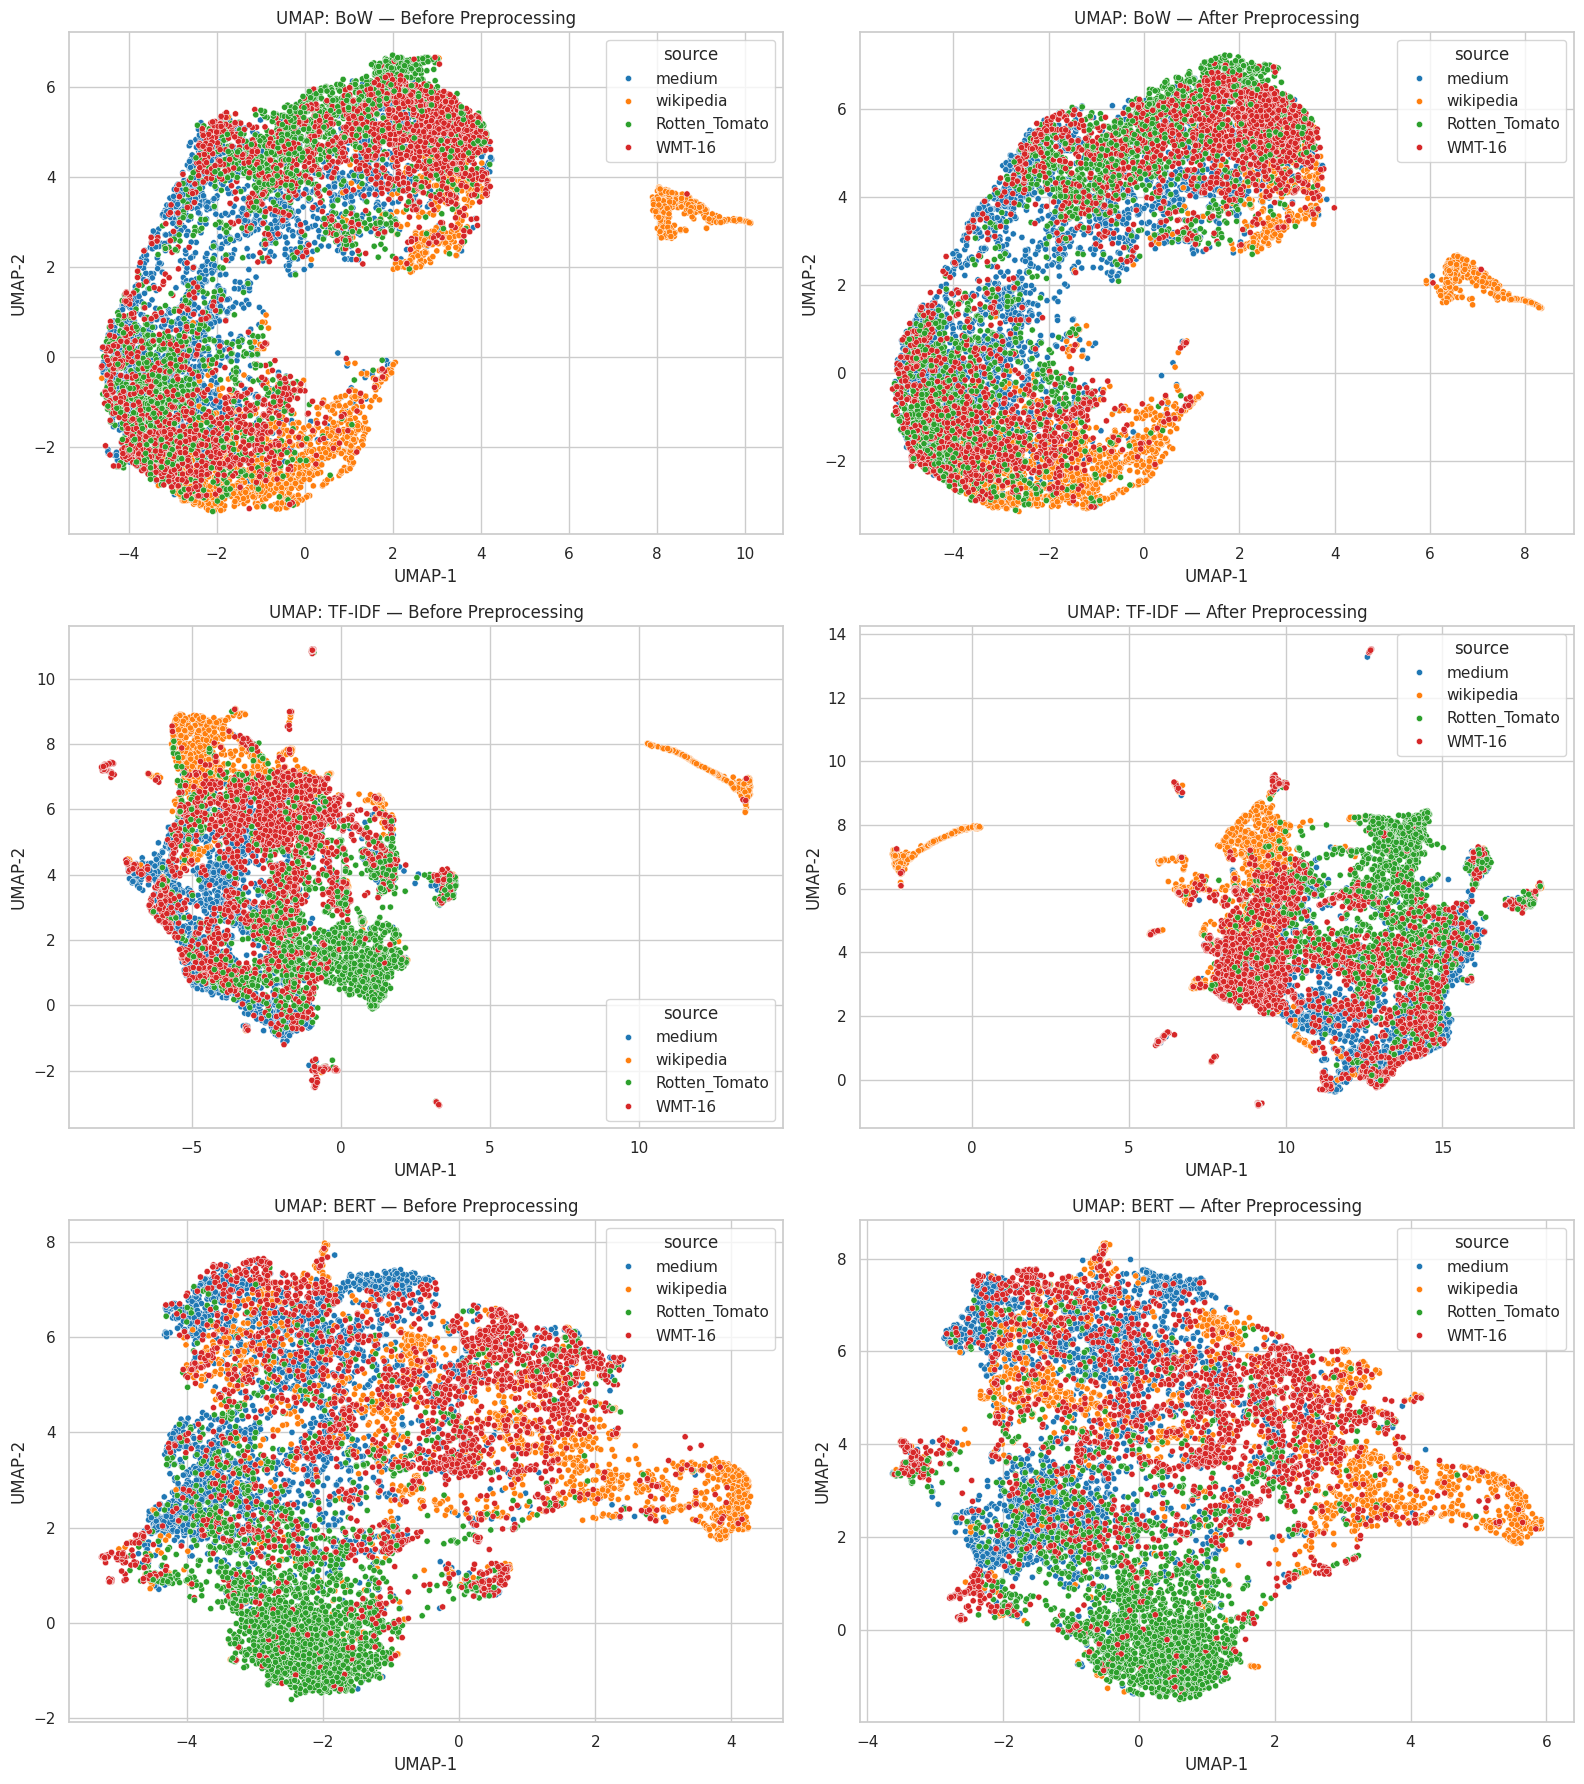

In [ ]:
# ==============================================
# INSTALL LIBRARIES (run once)
# ==============================================
# pip install pandas scikit-learn umap-learn sentence-transformers seaborn matplotlib


# ==============================================
# IMPORT LIBRARIES
# ==============================================
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA

import umap

from sentence_transformers import SentenceTransformer


# ==============================================
# LOAD DATASET
# ==============================================
# Replace with your dataset path
df = pd.read_csv("/content/5000human_5000machine.csv")

# Expected columns
# text , source

print("Dataset shape:", df.shape)
print(df.head())


# ==============================================
# TEXT PREPROCESSING
# ==============================================
def preprocess_text(text):

    text = str(text).lower()

    # remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


df["processed_text"] = df["text"].apply(preprocess_text)


# ==============================================
# UMAP FUNCTION
# ==============================================
def compute_umap(embeddings):

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        metric="cosine",
        random_state=42
    )

    return reducer.fit_transform(embeddings)


# ==============================================
# VECTOR REPRESENTATIONS
# ==============================================

# -------- BoW --------
bow = CountVectorizer(max_features=5000)

bow_before = bow.fit_transform(df["text"]).toarray()
bow_after = bow.fit_transform(df["processed_text"]).toarray()


# -------- TF-IDF --------
tfidf = TfidfVectorizer(max_features=5000)

tfidf_before = tfidf.fit_transform(df["text"]).toarray()
tfidf_after = tfidf.fit_transform(df["processed_text"]).toarray()


# -------- BERT --------
print("Loading BERT model...")

bert_model = SentenceTransformer("all-MiniLM-L6-v2")

print("Generating BERT embeddings...")

bert_before = bert_model.encode(
    df["text"].tolist(),
    show_progress_bar=True
)

bert_after = bert_model.encode(
    df["processed_text"].tolist(),
    show_progress_bar=True
)


# ==============================================
# OPTIONAL PCA (improves UMAP for sparse vectors)
# ==============================================
pca = PCA(n_components=50)

bow_before = pca.fit_transform(bow_before)
bow_after = pca.fit_transform(bow_after)

tfidf_before = pca.fit_transform(tfidf_before)
tfidf_after = pca.fit_transform(tfidf_after)


# ==============================================
# COMPUTE UMAP EMBEDDINGS
# ==============================================
print("Computing UMAP...")

umap_bow_before = compute_umap(bow_before)
umap_bow_after = compute_umap(bow_after)

umap_tfidf_before = compute_umap(tfidf_before)
umap_tfidf_after = compute_umap(tfidf_after)

umap_bert_before = compute_umap(bert_before)
umap_bert_after = compute_umap(bert_after)


# ==============================================
# PLOT UMAP VISUALIZATIONS
# ==============================================
sns.set(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))


# BoW BEFORE
sns.scatterplot(
    x=umap_bow_before[:,0],
    y=umap_bow_before[:,1],
    hue=df["source"],
    palette="tab10",
    ax=axes[0,0],
    s=20
)

axes[0,0].set_title("UMAP: BoW — Before Preprocessing")
axes[0,0].set_xlabel("UMAP-1")
axes[0,0].set_ylabel("UMAP-2")


# BoW AFTER
sns.scatterplot(
    x=umap_bow_after[:,0],
    y=umap_bow_after[:,1],
    hue=df["source"],
    palette="tab10",
    ax=axes[0,1],
    s=20
)

axes[0,1].set_title("UMAP: BoW — After Preprocessing")
axes[0,1].set_xlabel("UMAP-1")
axes[0,1].set_ylabel("UMAP-2")


# TF-IDF BEFORE
sns.scatterplot(
    x=umap_tfidf_before[:,0],
    y=umap_tfidf_before[:,1],
    hue=df["source"],
    palette="tab10",
    ax=axes[1,0],
    s=20
)

axes[1,0].set_title("UMAP: TF-IDF — Before Preprocessing")
axes[1,0].set_xlabel("UMAP-1")
axes[1,0].set_ylabel("UMAP-2")


# TF-IDF AFTER
sns.scatterplot(
    x=umap_tfidf_after[:,0],
    y=umap_tfidf_after[:,1],
    hue=df["source"],
    palette="tab10",
    ax=axes[1,1],
    s=20
)

axes[1,1].set_title("UMAP: TF-IDF — After Preprocessing")
axes[1,1].set_xlabel("UMAP-1")
axes[1,1].set_ylabel("UMAP-2")


# BERT BEFORE
sns.scatterplot(
    x=umap_bert_before[:,0],
    y=umap_bert_before[:,1],
    hue=df["source"],
    palette="tab10",
    ax=axes[2,0],
    s=20
)

axes[2,0].set_title("UMAP: BERT — Before Preprocessing")
axes[2,0].set_xlabel("UMAP-1")
axes[2,0].set_ylabel("UMAP-2")


# BERT AFTER
sns.scatterplot(
    x=umap_bert_after[:,0],
    y=umap_bert_after[:,1],
    hue=df["source"],
    palette="tab10",
    ax=axes[2,1],
    s=20
)

axes[2,1].set_title("UMAP: BERT — After Preprocessing")
axes[2,1].set_xlabel("UMAP-1")
axes[2,1].set_ylabel("UMAP-2")


plt.tight_layout()

# Save figure for research paper
plt.savefig("umap_all_models.png", dpi=300, bbox_inches="tight")

plt.show()